# *First we import our libaries *

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import zipfile

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Bring our dataset to project

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dragonheir/logistic-regression")

print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 1.34MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dragonheir/logistic-regression/versions/1


## Starting our EDA

In [3]:
csv_path = os.path.join(path, "Social_Network_Ads.csv")

df_ads = pd.read_csv(csv_path)
df_ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df_ads.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df_ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


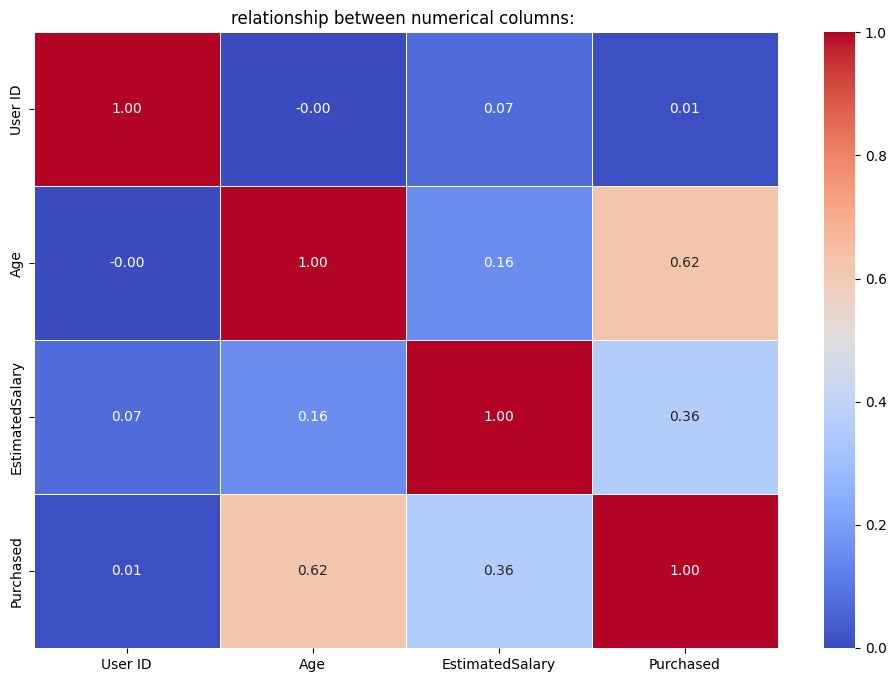

In [6]:
numeric_df = df_ads.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,       # Show numbers inside the boxes
            cmap='coolwarm',  # Choose a color map for positive/negative values
            fmt=".2f",        # Round to two decimal places
            linewidths=0.5)

plt.title("relationship between numerical columns: ")
plt.show()

In [7]:
columns_to_check = ['Age', 'EstimatedSalary']

# Function to detect outliers mathematically using the IQR method
def detect_outliers_iqr(data, column):
    # Calculate Q1 (25%) and Q3 (75%)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Calculate the Interquartile Range
    IQR = Q3 - Q1

    # Determine the upper and lower bounds for normal data
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Extract rows that exceed these bounds (outliers)
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Apply the function to the columns and print results
for col in columns_to_check:
    outliers_df = detect_outliers_iqr(df_ads, col)

    print(f"--- Outlier check results for: {col} ---")
    if outliers_df.empty:
        print("✅ No outliers found.")
    else:
        print(f"⚠️ Found {len(outliers_df)} outliers:")
        print(outliers_df)
    print("-" * 40 + "\n")

--- Outlier check results for: Age ---
✅ No outliers found.
----------------------------------------

--- Outlier check results for: EstimatedSalary ---
✅ No outliers found.
----------------------------------------



In [8]:
missing_values = df_ads.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


# **Doing the encoding and Scaling on our data.**

In [9]:
X = df_ads.drop('Purchased', axis=1)
y = df_ads['Purchased']

# 2. Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dimensions to confirm successful split
print("Training data shape X_train:", X_train.shape)
print("Test data shape X_test:", X_test.shape)
print("Training labels shape y_train:", y_train.shape)
print("Test labels shape y_test:", y_test.shape)

Training data shape X_train: (320, 4)
Test data shape X_test: (80, 4)
Training labels shape y_train: (320,)
Test labels shape y_test: (80,)


In [10]:
le = LabelEncoder()

# Apply encoding to the Gender column in training data (fit_transform)
X_train['Gender'] = le.fit_transform(X_train['Gender'])

# Apply encoding to the same column in test data (transform only)
X_test['Gender'] = le.transform(X_test['Gender'])


X_train = X_train.drop('User ID', axis=1)
X_test = X_test.drop('User ID', axis=1)

In [11]:
scaler = StandardScaler()
cols_to_scale = ['Age', 'EstimatedSalary']


X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])


X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [12]:
# Check data dimensions (number of rows and columns)
print("Dimensions of X_train:", X_train.shape)
print("Dimensions of X_test:", X_test.shape)
print("-" * 50)


print("First 5 rows of training data:")
display(X_train.head())
print("-" * 50)


print("Statistical summary of training data after scaling:")
display(X_train.describe().round(3))

Dimensions of X_train: (320, 3)
Dimensions of X_test: (80, 3)
--------------------------------------------------
First 5 rows of training data:


,Gender,Age,EstimatedSalary
3,0,-1.066752,-0.386344
18,1,0.797535,-1.229939
202,0,0.110692,1.853544
250,0,0.601294,-0.909955
274,0,1.876859,-1.288118


--------------------------------------------------
Statistical summary of training data after scaling:


,Gender,Age,EstimatedSalary
count,320.000,320.000,320.000
mean,0.500,-0.000,0.000
std,0.501,1.002,1.002
min,0.000,-1.950,-1.608
25%,0.000,-0.772,-0.794
50%,0.500,-0.086,0.021
75%,1.000,0.699,0.515
max,1.000,2.171,2.319


## Let's train more than a model and see how it's going to be

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd


log_reg = LogisticRegression(random_state=42)

# =====================================================================
# 2. Cross-Validation equivalent to Stratified K-Fold
# =====================================================================
print("--- Cross Validation Results ---")
# cv=5 means it splits data into 5 folds for training and testing
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy for each of the five folds: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print("="*50 + "\n")

--- Cross Validation Results ---
Accuracy for each of the five folds: [0.796875 0.859375 0.828125 0.78125  0.8125  ]
Mean Accuracy: 0.8156
Standard Deviation: 0.0269



In [14]:
# =====================================================================
# 3. Final Model Training and Prediction
# =====================================================================
# Train on all of X_train and y_train
log_reg.fit(X_train, y_train)

# Predict using test data X_test
y_pred = log_reg.predict(X_test)

# =====================================================================
# 4. Model Parameters (Mathematical Statistics)
# =====================================================================
print("--- Model Statistics (Mathematical) ---")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print("Weights/Coefficients for each column:")
# Print weight of each feature to see its influence on the decision
for col, coef in zip(X_train.columns, log_reg.coef_[0]):
    print(f"  - {col}: {coef:.4f}")
print("="*50 + "\n")

# =====================================================================
# 5. Evaluation Metrics
# =====================================================================
print("--- Performance Evaluation Metrics ---")
print(f"1. Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"2. Prediction Precision: {precision_score(y_test, y_pred):.4f}")
print(f"3. Model Recall: {recall_score(y_test, y_pred):.4f}")
print(f"4. F1-Score: {f1_score(y_test, y_pred):.4f}")

--- Model Statistics (Mathematical) ---
Intercept: -1.1323
Weights/Coefficients for each column:
  - Gender: 0.2561
  - Age: 1.9879
  - EstimatedSalary: 1.1442

--- Performance Evaluation Metrics ---
1. Overall Accuracy: 0.8875
2. Prediction Precision: 0.9130
3. Model Recall: 0.7500
4. F1-Score: 0.8235


In [15]:
print("\n---(Classification Report) ---")
print(classification_report(y_test, y_pred))


---(Classification Report) ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


log_reg = LogisticRegression(random_state=42)

# =====================================================================
# 2. Cross-validation while retaining models (return_estimator=True)
# =====================================================================
# cross_validate returns a dictionary containing training times, scores, and models
cv_results = cross_validate(log_reg, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

# Extract accuracy scores for each fold
scores = cv_results['test_score']
print("--- Cross-Validation Results (Stratified K-Fold) ---")
print(f"Accuracy scores per fold: {scores}")

# =====================================================================
# 3. Find and extract the best model
# =====================================================================
# argmax from numpy gives the index of the highest value in the array
best_fold_index = np.argmax(scores)

print(f"\nBest fold was fold number: {best_fold_index + 1} with accuracy: {scores[best_fold_index]:.4f}")


best_model = cv_results['estimator'][best_fold_index]
print("Best model extracted successfully!\n")
print("="*50 + "\n")

# =====================================================================
# 4. Prediction and evaluation using only the best model
# =====================================================================

y_pred_best = best_model.predict(X_test)

print("--- (Best Model) performance on X_test ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

--- Cross-Validation Results (Stratified K-Fold) ---
Accuracy scores per fold: [0.796875 0.859375 0.828125 0.78125  0.8125  ]

Best fold was fold number: 2 with accuracy: 0.8594
Best model extracted successfully!


--- (Best Model) performance on X_test ---
Overall Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        52
           1       0.92      0.79      0.85        28

    accuracy                           0.90        80
   macro avg       0.90      0.87      0.89        80
weighted avg       0.90      0.90      0.90        80



In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd
import numpy as np

# 1. Initialize SVM model with RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)

# =====================================================================
# 2. Cross-validation while retaining models (Stratified K-Fold)
# =====================================================================
print("--- Cross-Validation Results (Stratified K-Fold) for SVM Model ---")
cv_results = cross_validate(svm_model, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

scores = cv_results['test_score']
print(f"Accuracy scores per fold: {scores}")

# =====================================================================
# 3. Find and extract the best model
# =====================================================================
best_fold_index = np.argmax(scores)
print(f"\nBest fold was fold number: {best_fold_index + 1} with accuracy: {scores[best_fold_index]:.4f}")

best_svm_model = cv_results['estimator'][best_fold_index]
print("Best SVM model extracted successfully!\n")
print("="*50 + "\n")

--- Cross-Validation Results (Stratified K-Fold) for SVM Model ---
Accuracy scores per fold: [0.921875 0.96875  0.875    0.875    0.890625]

Best fold was fold number: 2 with accuracy: 0.9688
Best SVM model extracted successfully!




In [18]:
# =====================================================================
# 4. Prediction using the best model
# =====================================================================
y_pred_best_svm = best_svm_model.predict(X_test)

# =====================================================================
# 5. Model Statistics - adjusted for non-linear kernel
# =====================================================================
print("--- SVM Model Statistics ---")
print(f"Kernel type used: {best_svm_model.kernel}")
print(f"Total number of Support Vectors the model relied on: {len(best_svm_model.support_)}")
# The weights (coef_) and intercept (intercept_) have been removed because they are incompatible with the RBF kernel.
print("="*50 + "\n")

# =====================================================================
# 6. Evaluation Metrics
# =====================================================================
print("--- (Best SVM Model) performance on X_test ---")
print(f"1. Overall Accuracy: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(f"2. Prediction Precision: {precision_score(y_test, y_pred_best_svm):.4f}")
print(f"3. Model Recall: {recall_score(y_test, y_pred_best_svm):.4f}")
print(f"4. F1-Score: {f1_score(y_test, y_pred_best_svm):.4f}")

print("\n--- Confusion Matrix ---")
cm_svm = confusion_matrix(y_test, y_pred_best_svm)
cm_svm_df = pd.DataFrame(cm_svm,
                         columns=['Predicted 0 (Did not buy)', 'Predicted 1 (Bought)'],
                         index=['Actual 0', 'Actual 1'])
print(cm_svm_df)

print("\n--- Comprehensive Report (Classification Report) ---")
print(classification_report(y_test, y_pred_best_svm))

--- SVM Model Statistics ---
Kernel type used: rbf
Total number of Support Vectors the model relied on: 86

--- (Best SVM Model) performance on X_test ---
1. Overall Accuracy: 0.9250
2. Prediction Precision: 0.8667
3. Model Recall: 0.9286
4. F1-Score: 0.8966

--- Confusion Matrix ---
          Predicted 0 (Did not buy)  Predicted 1 (Bought)
Actual 0                         48                     4
Actual 1                          2                    26

--- Comprehensive Report (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd
import numpy as np

# 1. Initialize KNN model
# We will choose the initial number of neighbors to be 5, which is the default and most common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)

# =====================================================================
# 2. Cross-validation while retaining models (Stratified K-Fold)
# =====================================================================
print("--- Cross-Validation Results (Stratified K-Fold) for KNN Model ---")
cv_results = cross_validate(knn_model, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

scores = cv_results['test_score']
print(f"Accuracy scores per fold: {scores}")

# =====================================================================
# 3. Find and extract the best model
# =====================================================================
best_fold_index = np.argmax(scores)
print(f"\nBest fold was fold number: {best_fold_index + 1} with accuracy: {scores[best_fold_index]:.4f}")

best_knn_model = cv_results['estimator'][best_fold_index]
print("Best KNN model extracted successfully!\n")
print("="*50 + "\n")

--- Cross-Validation Results (Stratified K-Fold) for KNN Model ---
Accuracy scores per fold: [0.890625 0.96875  0.859375 0.875    0.890625]

Best fold was fold number: 2 with accuracy: 0.9688
Best KNN model extracted successfully!




In [20]:
# 4. Prediction using the best model

y_pred_best_knn = best_knn_model.predict(X_test)


# 5. Model Statistics (Mathematical / Structural)

print("--- Internal Structure Statistics of the Best KNN Model ---")
print(f"Number of neighbors (K) adopted in the decision: {best_knn_model.n_neighbors}")
print(f"Distance metric type used: {best_knn_model.metric} (where minkowski with p=2 equals Euclidean distance)")
print(f"Total number of training points the model stores to calculate distances: {best_knn_model.n_samples_fit_}")
print("="*50 + "\n")

# =====================================================================
# 6. Evaluation Metrics
# =====================================================================
print("--- (Best KNN Model) performance on X_test ---")
print(f"1. Overall Accuracy: {accuracy_score(y_test, y_pred_best_knn):.4f}")
print(f"2. Prediction Precision: {precision_score(y_test, y_pred_best_knn):.4f}")
print(f"3. Model Recall: {recall_score(y_test, y_pred_best_knn):.4f}")
print(f"4. F1-Score: {f1_score(y_test, y_pred_best_knn):.4f}")

print("\n--- Confusion Matrix ---")
cm_knn = confusion_matrix(y_test, y_pred_best_knn)
cm_knn_df = pd.DataFrame(cm_knn,
                         columns=['Predicted 0 (Did not buy)', 'Predicted 1 (Bought)'],
                         index=['Actual 0', 'Actual 1'])
print(cm_knn_df)

print("\n--- Comprehensive Report (Classification Report) ---")
print(classification_report(y_test, y_pred_best_knn))

--- Internal Structure Statistics of the Best KNN Model ---
Number of neighbors (K) adopted in the decision: 5
Distance metric type used: minkowski (where minkowski with p=2 equals Euclidean distance)
Total number of training points the model stores to calculate distances: 256

--- (Best KNN Model) performance on X_test ---
1. Overall Accuracy: 0.9375
2. Prediction Precision: 0.8966
3. Model Recall: 0.9286
4. F1-Score: 0.9123

--- Confusion Matrix ---
          Predicted 0 (Did not buy)  Predicted 1 (Bought)
Actual 0                         49                     3
Actual 1                          2                    26

--- Comprehensive Report (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94 